# **Dataset**

In [ ]:
import pandas as pd
import numpy as np
import torch
import gc
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch import nn

torch.cuda.empty_cache()
gc.collect()
df = pd.read_csv('/content/Domain_Data.csv')
df

,Unnamed: 0,domain_name,unified_sentiment,Sentences_clean,Aspects_clean,Aspects_sentiments_list,Aspects_list
0,0,Attractions,1.0,نصحوني بتجربه حمام الكبريت يمكنكم الدخول مع مج...,الحمام، العاملات، الانجليزيه,"[1, 1, -1]","['الحمام', 'العاملات', 'الانجليزيه']"
1,1,Attractions,1.0,قلعه ساحره منظر خلاب للمدينه من اعلي القلعه يو...,قلعه، منظر، حديقه نباتات، مجري مائي,"[1, 1, 1, 1]","['قلعه', 'منظر', 'حديقه نباتات', 'مجري مائي']"
2,2,Attractions,1.0,تبليسي جورجيا من اجمل المدن التي زرتها في حيات...,تبليسي جورجيا، شعبها، الحياه,"[1, 1, 1]","['تبليسي جورجيا', 'شعبها', 'الحياه']"
3,3,Attractions,1.0,جوله علي المدينه القديمه تبليسي شاردن ممتعه ال...,المدينه القديمه تبليسي، الجوله، جلساتها، تلفري...,"[1, 1, 1, 1, 1, 1]","['المدينه القديمه تبليسي', 'الجوله', 'جلساتها'..."
4,4,Attractions,1.0,احلي اجازه لمحبي الطبيعه المناظر الخلابه الطبي...,اجازه، المناظر، الاجواء، ميزه,"[1, 1, 1, 0]","['اجازه', 'المناظر', 'الاجواء', 'ميزه']"
...,...,...,...,...,...,...,...
16673,3195,Hotels,0.0,بصراحة، الغرفة كانت عادية وتفي بالغرض. الاستقب...,الغرفة، الاستقبال، الإفطار، الموقع,"[0, 0, 0, 0]","['الغرفة', 'الاستقبال', 'الإفطار', 'الموقع']"
16674,3196,Hotels,1.0,قمت بتجربة هذا المكان وملاحظاتي هي: أعجبتني ال...,الغرفة، الاستقبال,"[1, 0]","['الغرفة', 'الاستقبال']"
16675,3197,Restaurants,0.0,خلال عطلة نهاية الأسبوع ذهبنا إلى هناك، نظافة ...,النظافة، الخدمة، الأسعار، الأكل,"[0, 0, 1, 0]","['النظافة', 'الخدمة', 'الأسعار', 'الأكل']"
16676,3198,Restaurants,0.0,خلال عطلة نهاية الأسبوع ذهبنا إلى هناك، الأسعا...,الأسعار، الأكل، النظافة، الخدمة,"[-1, 1, -1, 0]","['الأسعار', 'الأكل', 'النظافة', 'الخدمة']"


# **Arabert with adding domain hotel (before improving neutral)**

In [ ]:
texts = df['Sentences_clean'].astype(str).tolist()
labels = df['unified_sentiment'].tolist()
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)
X_train, X_test, y_train, y_test = train_test_split(texts, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels)

MODEL_NAME = "aubmindlab/bert-base-arabertv2"
print(f"Downloading Tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dataset = Dataset.from_dict({"text": X_train, "label": y_train})
test_dataset = Dataset.from_dict({"text": X_test, "label": y_test})

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing data...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}
print(f"Downloading {MODEL_NAME} Model...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./arabert_results",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print(f"Starting Training with {MODEL_NAME} on the massive dataset...")
trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2696, training_loss=1.4100592978276556, metrics={'train_runtime': 691.6702, 'train_samples_per_second': 62.353, 'train_steps_per_second': 3.898, 'total_flos': 2836888869943296.0, 'train_loss': 1.4100592978276556, 'epoch': 4.0})

# **Improving neutrals**

# **LR+TFIDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF Vectorization complete.")

TF-IDF Vectorization complete.


In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear') # Increased max_iter for convergence
lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained.")

Logistic Regression model trained.



Classification Report: Logistic Regression with TF-IDF
              precision    recall  f1-score   support

        -1.0       0.88      0.78      0.83      1039
         0.0       0.81      0.76      0.79       478
         1.0       0.87      0.94      0.90      1819

    accuracy                           0.86      3336
   macro avg       0.85      0.83      0.84      3336
weighted avg       0.86      0.86      0.86      3336



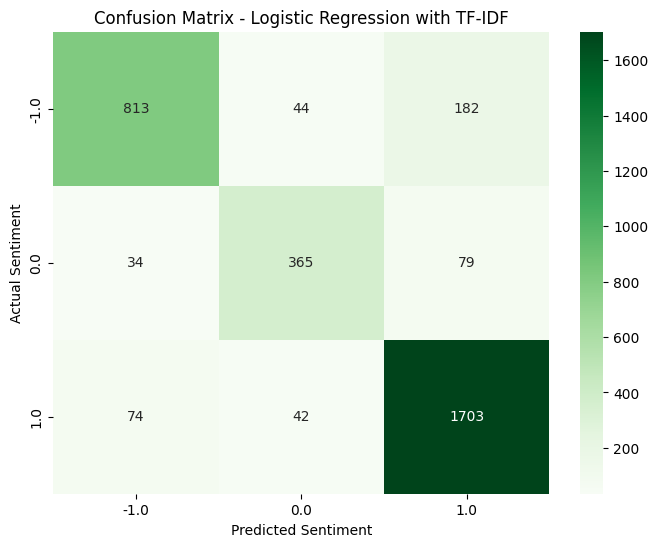

In [ ]:
y_pred_lr = lr_model.predict(X_test_tfidf)
target_names_lr = [str(cls) for cls in encoder.classes_]
print("\n" + "="*60)
print("Classification Report: Logistic Regression with TF-IDF")
print("="*60)
print(classification_report(y_test, y_pred_lr, target_names=target_names_lr))
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names_lr, yticklabels=target_names_lr)
plt.title('Confusion Matrix - Logistic Regression with TF-IDF')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

# **Arabert**

In [ ]:
texts = df['Sentences_clean'].astype(str).tolist()
labels = df['unified_sentiment'].tolist()
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)
X_train, X_test, y_train, y_test = train_test_split(texts, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels)

MODEL_NAME = "aubmindlab/bert-base-arabertv2"
print(f"Downloading Tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dataset = Dataset.from_dict({"text": X_train, "label": y_train})
test_dataset = Dataset.from_dict({"text": X_test, "label": y_test})

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing data...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}
print(f"Downloading {MODEL_NAME} Model...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./arabert_results",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print(f"Starting Training with {MODEL_NAME} on the massive dataset...")
trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizing data...


Map:   0%|          | 0/13342 [00:00<?, ? examples/s]

Map:   0%|          | 0/3336 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3336, training_loss=1.009249067420868, metrics={'train_runtime': 936.2057, 'train_samples_per_second': 57.005, 'train_steps_per_second': 3.563, 'total_flos': 3510459219326976.0, 'train_loss': 1.009249067420868, 'epoch': 4.0})

Predicting on Test Data with Arabert...



Final Classification Report: Arabert
              precision    recall  f1-score   support

        -1.0       0.94      0.90      0.92      1039
         0.0       0.90      0.87      0.88       478
         1.0       0.93      0.96      0.94      1819

    accuracy                           0.93      3336
   macro avg       0.92      0.91      0.92      3336
weighted avg       0.93      0.93      0.93      3336



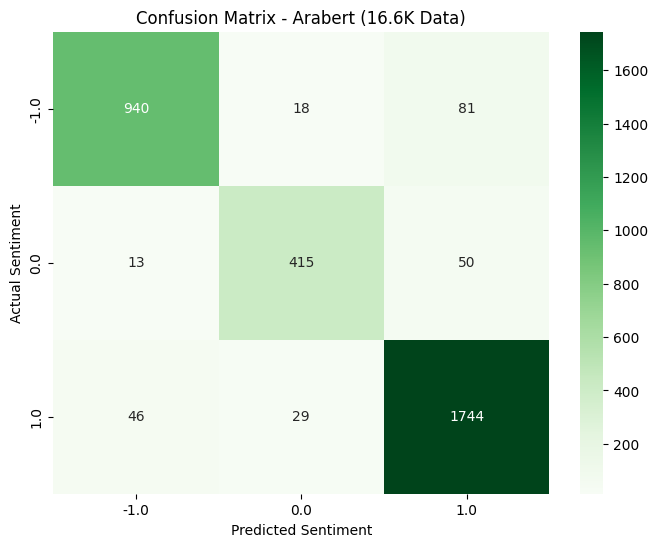

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Predicting on Test Data with Arabert...")
predictions_output = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids
target_names = [str(cls) for cls in encoder.classes_]
print("\n" + "="*60)
print("Final Classification Report: Arabert")
print("="*60)
print(classification_report(y_true, y_pred, target_names=target_names))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
a
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Arabert (16.6K Data)')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

# **CamelBert**

In [ ]:
texts = df['Sentences_clean'].astype(str).tolist()
labels = df['unified_sentiment'].tolist()
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)
X_train, X_test, y_train, y_test = train_test_split(texts, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels)

MODEL_NAME = "CAMeL-Lab/bert-base-arabic-camelbert-mix"
print(f"Downloading Tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dataset = Dataset.from_dict({"text": X_train, "label": y_train})
test_dataset = Dataset.from_dict({"text": X_test, "label": y_test})

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing data...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}
print(f"Downloading {MODEL_NAME} Model...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./arabert_results",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print(f"Starting Training with {MODEL_NAME} on the massive dataset...")
trainer.train()

config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizing data...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.692201,0.336762,0.910671,0.908914,0.911093,0.910671
2,0.914399,0.356324,0.920264,0.920346,0.920622,0.920264
3,0.684867,0.431078,0.927758,0.927396,0.927566,0.927758
4,0.384542,0.466191,0.929856,0.929716,0.929710,0.929856


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3336, training_loss=0.8805047225037352, metrics={'train_runtime': 840.381, 'train_samples_per_second': 63.505, 'train_steps_per_second': 3.97, 'total_flos': 3510459219326976.0, 'train_loss': 0.8805047225037352, 'epoch': 4.0})

Predicting on Test Data with camelbert...



Final Classification Report: camelbert
              precision    recall  f1-score   support

        -1.0       0.93      0.91      0.92      1039
         0.0       0.89      0.88      0.89       478
         1.0       0.94      0.95      0.95      1819

    accuracy                           0.93      3336
   macro avg       0.92      0.91      0.92      3336
weighted avg       0.93      0.93      0.93      3336



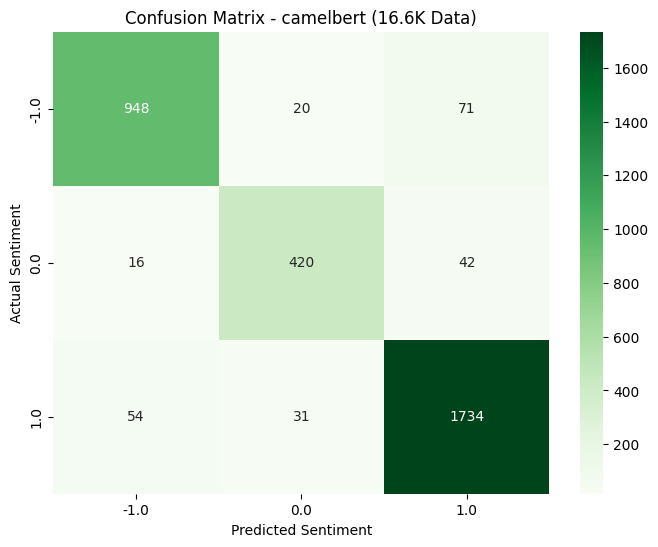

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Predicting on Test Data with camelbert...")
predictions_output = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids
target_names = [str(cls) for cls in encoder.classes_]
print("\n" + "="*60)
print("Final Classification Report: camelbert")
print("="*60)
print(classification_report(y_true, y_pred, target_names=target_names))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - camelbert (16.6K Data)')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()